# Lab 1

Data itself is a distribution. Empirical CDF is a way to convert data into a distribution.

Draw a CDF from the following sequence of dice rolls:
$$[5, 4, 4, 1, 4, 3, 6]$$

Study the details of the CDF and compare it to the definition of CDF.

<Axes: >

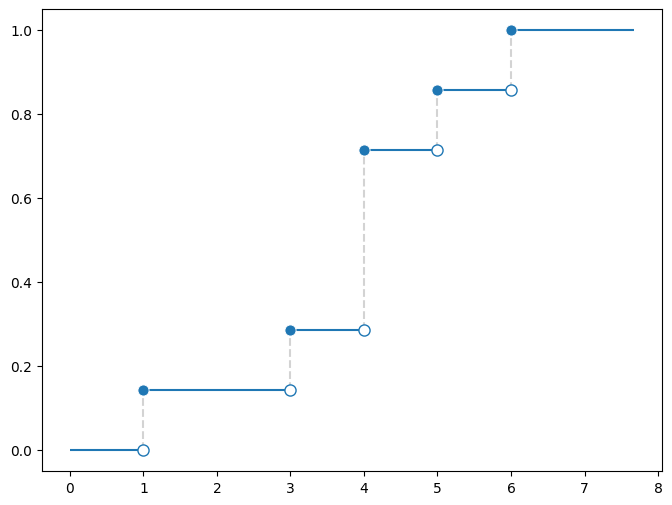

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create an empty plot
fig, ax = plt.subplots(figsize=(8, 6))

def ecdf (data):

  v, c = np.unique(data, return_counts=True)
  Fhat = np.cumsum(c/sum(c))

  return v, Fhat

def plot_ecdf(data, dash_color='lightgray', ax=None, labels=None, Fhat=None):
  """
  Plot empirical cumulative distribution function (ECDF) with extended range.
  
  Parameters:
  -----------
  data : array-like
      Input data for ECDF calculation
      
  Returns:
  --------
  fig, ax : matplotlib figure and axis objects
  """
  
  if ax is None:
    fig, ax = plt.subplots()

  if Fhat is None:
    v, Fhat = ecdf(data)
  else:
    v = data
  # v, Fhat = ecdf(data)
  
  extension = (data.max() - data.min())/3
  marker_size = np.diff(Fhat).mean()*300

  if ax.lines or ax.collections:

    # figure out data range from axis limits and margins
    xmin, xmax = ax.get_xlim()
    lmar, rmar = ax.margins()
    data_rng = (xmax - xmin)/(1 + lmar + rmar)
    dmin = xmin + lmar*data_rng
    dmax = xmax - rmar*data_rng

    v = np.insert(v, 0, dmin)
    v = np.append(v, dmax)

  else:

    v = np.insert(v, 0, v[0]-extension)
    v = np.append(v, v[-1]+extension)

  Fhat = np.insert(Fhat, 0, 0)

  sns.scatterplot(x=v[1:-1], y=Fhat[1:], s=marker_size, ax=ax, zorder=2, legend=False)
  c = ax.collections[-1].get_facecolors()
  sns.scatterplot(x=v[1:-1], y=Fhat[:-1], s=marker_size, color="white", edgecolor=c, linewidth=1, ax=ax, zorder=2, legend=False)

  # Draw flat lines and dashed vertical lines
  ax.hlines(y=Fhat, xmin=v[:-1], xmax=v[1:], color=c, zorder=1, label=labels)
  ax.vlines(x=v[1:-1], ymin=Fhat[:-1], ymax=Fhat[1:], color=dash_color, linestyle='dashed', zorder=1)
    
  return ax

x_data = np.array([5, 4, 4, 1, 4, 3, 6])

# Empirical CDF as a step plot
plot_ecdf(x_data, ax=ax, labels='Empirical CDF: Fhat(x)')



In lecture, we saw a plugin estimator (plugging in estimated probability function) results in a sample statistic: i.e., sample mean is 

$$\hat{\mu}_{\hat{F}} = \underbrace{E_{\hat{F}}(X) = \sum_{i=1}^n x_i \cdot \hat{p}(x_i)}_\text{Plugin Estimator} = \underbrace{\frac{1}{n} \sum_{i=1}^n x_i = \bar{x}}_\text{Sample Statistic}$$

We will verify that the equality holds with numerical calculation for above.

Furthermore, we will also compute a plugin estimate $E_{\hat F}[g(X)]$ of some function, $g(x)$, from empirically estimated probability function, and verify the equality.

## Simulate data

Let's simulate a data from two dice rolls, $X$ and $Y$. We would like to estimate the distribution from the sum, $Z = X+Y$.

In [2]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of times to roll two dice
n = 10000

# Simulate rolling two dice n times
X = np.random.randint(1, 7, size=n)  # First die: values 1-6
Y = np.random.randint(1, 7, size=n)  # Second die: values 1-6

# Calculate the sum of two dice for each roll
Z = X + Y

# Estimate the PMF from the data
# Count occurrences of each unique value
unique_values, counts = np.unique(Z, return_counts=True)

# Calculate the estimated probabilities
p_hat = counts / n

# Display the estimated PMF
pmf_df = pd.DataFrame({
    'z_i': unique_values,
    'count': counts,
    'p_hat(z_i)': p_hat
})

print(f"Mean dice sum: {Z.mean():.2f}")

print("Estimated PMF from simulated data:")
print(f"\nTotal rolls: {n}")
print(pmf_df)

Mean dice sum: 7.00
Estimated PMF from simulated data:

Total rolls: 10000
    z_i  count  p_hat(z_i)
0     2    273      0.0273
1     3    608      0.0608
2     4    811      0.0811
3     5   1101      0.1101
4     6   1383      0.1383
5     7   1616      0.1616
6     8   1414      0.1414
7     9   1105      0.1105
8    10    858      0.0858
9    11    556      0.0556
10   12    275      0.0275


## Example 1: Sample Mean

We will compute the plugin estimate first.

Plugin estimator is,

$$E_{\hat{F}}(Z) = \sum_{i=1}^k z_i \cdot \hat{p}(z_i)$$

Compute this expression from `pmf_df['z_i']` and `pmf_df['p_hat(z_i)']`:

In [3]:
(pmf_df['z_i']*pmf_df['p_hat(z_i)']).sum()  # Expected value calculation

np.float64(6.998200000000001)

Next, compute the sample mean from observations `Z` directly.

Sample statistic is,

$$\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i $$


In [4]:
Z.mean()

np.float64(6.9982)

## Example 2: Expected Earnings (The "Gamer's" Expectation)

In games like Craps, specific sums have different values. You can compute the expected "payout" of a roll by assigning a value $g(Z)$ to each sum.

**Example:** Suppose you win $10 if you roll a "7" or "11", but lose $5 otherwise.

$$E[\text{Profit}] = 10 \cdot P(Z \in \{7, 11\}) - 5 \cdot P(Z \notin \{7, 11\})$$

The rule can be a function $g(z)$ that returns a payout (or loss) given a value of sum of two dice outcomes.

Then, the expected payout (or loss) of $g(z)$ is:
$$E[g(Z)] = \sum_{z=2}^{12} g(z) \cdot \hat{p}(z)$$

Let's compute the expected profit using our estimated PMF.

In [5]:
# Define the payout function g(z)
def g(z):
    """
    Payout function: win $10 if roll is 7 or 11, lose $5 otherwise
    """
    if z in [7, 11]:
        return 10
    else:
        return -5

# Calculate expected profit using the estimated PMF
# E[g(Z)] = sum(g(z_i) * p_hat(z_i))
payouts = pmf_df['z_i'].apply(g)
expected_profit_plugin = (payouts * pmf_df['p_hat(z_i)']).sum()

print("Payout function:")
display_df = pmf_df.copy()
display_df['g(z_i)'] = payouts
display_df['g(z_i) * p_hat(z_i)'] = payouts * pmf_df['p_hat(z_i)']
print(display_df)

print(f"\nExpected Profit (Plugin Estimator): ${expected_profit_plugin:.2f}")

Payout function:
    z_i  count  p_hat(z_i)  g(z_i)  g(z_i) * p_hat(z_i)
0     2    273      0.0273      -5              -0.1365
1     3    608      0.0608      -5              -0.3040
2     4    811      0.0811      -5              -0.4055
3     5   1101      0.1101      -5              -0.5505
4     6   1383      0.1383      -5              -0.6915
5     7   1616      0.1616      10               1.6160
6     8   1414      0.1414      -5              -0.7070
7     9   1105      0.1105      -5              -0.5525
8    10    858      0.0858      -5              -0.4290
9    11    556      0.0556      10               0.5560
10   12    275      0.0275      -5              -0.1375

Expected Profit (Plugin Estimator): $-1.74


Another way to calculate the expected earnings is to calculate the earnings from outcomes. To do this, we count the number of wins vs. losses. Then, assign winnings (+$10) or losses (-$5) then taking an average.

In [6]:
# Verify using simulation: count wins and losses directly
wins = np.sum(np.isin(Z, [7, 11]))
losses = n - wins
expected_profit_simulation = (wins * 10 - losses * 5) / n

print(f"Expected Profit (Direct Simulation): ${expected_profit_simulation:.2f}")

# Show breakdown by outcome
print(f"\nBreakdown of outcomes:")
print(f"  Rolls of 7 or 11 (Win $10): {wins} rolls ({100*wins/n:.1f}%)")
print(f"  Other rolls (Lose $5): {losses} rolls ({100*losses/n:.1f}%)")

Expected Profit (Direct Simulation): $-1.74

Breakdown of outcomes:
  Rolls of 7 or 11 (Win $10): 2172 rolls (21.7%)
  Other rolls (Lose $5): 7828 rolls (78.3%)
